# Pareto Fronts and Time Series Generator for the Multi-Objective Optimisation of the Number of Repair Crews in the BPDRR

This notebook generates the visual representations (Pareto fronts and time series) of the results produced by the `MOO_BPDRR_NRC.ipynb` notebook.

The optimisation results are provided as two CSV files:

- **`pareto_OF_x.csv`**: contains the values of the objective functions for each solution obtained from the multi-objective optimisation process.
- **`pareto_solutions_x.csv`**: contains the repair order of the damaged pipes associated with each solution obtained from the multi-objective optimisation process.

This notebook requires three Python files specific to this research, which are used as modules:

- **`OF_BPDRR.py`**: Contains the functions used to calculate the objective functions from the BPDRR.
- **`RC_scheduling.py`**: Contains the functions used to estimate the allocation and scheduling of the repair crews.
- **`visuals_BPDRR.py`**: Contains the functions used to generate the Pareto fronts and time-series plots.

Please make sure that these modules are available in the appropriate directory and are imported correctly before running the notebook.

In [ ]:
# Import libraries to be used
import os
import wntr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Specialized libraries for this project
import OF_BPDRR as OF
import RC_scheduling as rcs
import visuals_BPDRR as visuals

### Selection of the scenario, specific solution, and number of crews

The cell below allows the user to select the following:

- **`ds_sel`**: Select one of the five damage scenarios to analyse (`DS1`, `DS2`, `DS3`, `DS4`, or `DS5`).
- **`sol_sel`**: Select one of the solutions obtained from the multi-objective optimisation process. This is only required if the user wants to generate the functionality and water-loss time series.
- **`n_crews`**: Specify the number of repair crews used in the optimisation process. This variable is used for labelling the plots.

In [2]:
# which damage scenario to analyse
ds_sel = 'DS3'  # Replace with the desired damage scenario (DS1, DS2, DS3, DS4, DS5, DS6)

# Select solution from the MOO to plot time series (From 0 to the number of solutions in the Pareto front)
sol_sel = 16  # Replace with the index of the desired solution

# Number of crews available for the restoration simulation
n_crews = 3

In [3]:
# Dictionary to store information for the plot title
plot_info = {
    "scenario": ds_sel,
    "solution": sol_sel,
    "crews": n_crews
}

In [4]:
# load the wdn as INP file WITH the broken pipes
inp_file = "BBM-EPS_"+ds_sel+"mcg.inp"

# Export the new INP file with the controls to a temporary file
temp_inp="temp_restoration_"+ds_sel+".inp"

# Load the water network model from the INP file
wn = wntr.network.WaterNetworkModel(inp_file)

In [5]:
# Simulation settings
wn.options.time.duration = 7 * 24 * 3600       # 7 days
wn.options.time.hydraulic_timestep = 15 * 60     # 15 minutes
wn.options.time.report_timestep = 15 * 60        # 15 minutes

# Start simulation at 07:00 AM
wn.options.time.start_clocktime = 7 * 3600

# Pressure Driven Analysis
wn.options.hydraulic.demand_model = "PDA"
wn.options.hydraulic.required_pressure = 20
wn.options.hydraulic.minimum_pressure = 0
wn.options.hydraulic.pressure_exponent = 0.5

In [6]:
# timestep
dt = wn.options.time.hydraulic_timestep

# timestep in minutes
dtm = dt/60

In [7]:
# Read the data from the excel file that contains the repair times for the selected damage scenario
df = pd.read_excel(
    "DS_with_full_description.xlsx",
    sheet_name= ds_sel
)

# Repair time discretization (hours)
repair_time_interval = 0.25  # 15 minutes

# Build the reparations dictionary
time_reparation = {}

for _, row in df.iterrows():

    repair_time = float(row["fix time (hours)"])

    # Round up to the nearest interval
    repair_time = np.ceil(repair_time / repair_time_interval) * repair_time_interval

    time_reparation[str(row["Pipe ID"])] = {
        "t_r": repair_time
    }

print(f"{len(time_reparation)} repairs loaded.")

132 repairs loaded.


In [8]:
# Find all demand nodes (base demand > 0)
demand_nodes = []

# Expected demand at each node

for node_name in wn.junction_name_list:

    node = wn.get_node(node_name)

    if node.base_demand > 0:

        demand_nodes.append(node_name)

print(f"Demand nodes found: {len(demand_nodes)}")

Demand nodes found: 4201


In [9]:
# Finding emitter nodes (nodes starting with "E_")
emitter_nodes = [
    j for j in wn.junction_name_list
    if j.startswith("E_")
]

# Demand at emitter nodes (leakage) over time
#leakage = demand[emitter_nodes]

In [10]:
# Expected demand
expected = wntr.metrics.expected_demand(wn)

expected *= 1000        # convert to L/s

expected = expected[demand_nodes]

expected.index = expected.index.astype(int)


In [11]:
# Pipe IDs from the reparations dictionary
pipe_ids = list(time_reparation.keys())

# Number of repairs
n_rep = len(pipe_ids)

In [12]:
# Import the travel time matrix from the parquet file
dmatrix_df = pd.read_parquet(
    "TravelTime_"+ds_sel+".parquet"
)

# Normalize IDs so the repair dictionary and matrix use the same keys
dmatrix_df.index = dmatrix_df.index.map(str)
dmatrix_df.columns = dmatrix_df.columns.map(str)


In [13]:
# The scenario dictionary contains all the information required to run the optimisation process
scenario = {

    # Restoration
    "damaged_inp": inp_file,
    "reparations": time_reparation,
    "dmatrix": dmatrix_df,
    "pipe_ids": pipe_ids,
    "n_crews": n_crews,
    "temp_inp": temp_inp,

    # Hydraulic data
    "demand_nodes": demand_nodes,
    "emitter_nodes": emitter_nodes,
    "expected": expected,

    # Time
    "dt": dt,
    "dtm": dtm,

    # Simulation settings
    "duration": wn.options.time.duration,
    "hydraulic_timestep": wn.options.time.hydraulic_timestep,
    "report_timestep": wn.options.time.report_timestep,

    "demand_model": wn.options.hydraulic.demand_model,
    "required_pressure": wn.options.hydraulic.required_pressure,
    "minimum_pressure": wn.options.hydraulic.minimum_pressure,
    "pressure_exponent": wn.options.hydraulic.pressure_exponent,

    # Objective constants
    "service_ratio": 0.5,
    "consecutive_hours": 8,

}

In [14]:
# Read the data from the csv file that contains the objective function values for the selected damage scenario MOO
data = pd.read_csv(f"pareto_OF_{ds_sel}_{n_crews}RC_moead(test).csv")

data

,Unnamed: 0,FH,t95,RL,TNS,NWSECH,WL
0,Solution 0,495.0,6900.0,20898.647137,47.452987,3.0,98144.039062
1,Solution 1,495.0,6900.0,20898.647137,47.452987,3.0,98144.039062
2,Solution 2,495.0,6900.0,20898.647137,47.452987,3.0,98144.039062
3,Solution 3,495.0,6900.0,20978.382393,47.427993,3.0,98218.710938
4,Solution 4,495.0,6900.0,20898.647137,47.452987,3.0,98144.039062
5,Solution 5,495.0,6900.0,20898.647137,47.452987,3.0,98144.039062
6,Solution 6,495.0,6900.0,20898.647137,47.452987,3.0,98144.039062
7,Solution 7,495.0,6900.0,20898.647137,47.452987,3.0,98144.039062
8,Solution 8,495.0,6900.0,20898.647137,47.452987,3.0,98144.039062
9,Solution 9,495.0,6900.0,20898.647137,47.452987,3.0,98144.039062


In [15]:
# Read the data from the csv file that contains the Pareto solutions for the selected damage scenario MOO
pareto_solutions = pd.read_csv(f"pareto_solutions_{ds_sel}_{n_crews}RC_moead(test).csv")

pareto_solutions[20:]

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,122,123,124,125,126,127,128,129,130,131


In [16]:
indexes = pareto_solutions.iloc[
    sol_sel, 1:
].to_numpy(dtype=int)

In [17]:
print(indexes)

[ 53  65  22  59  85   1  99   4   5  73  46   2  66   0  93  21  37  27  64   3 128  19  58  28  26  29  56  34  51  72  24  62 130  70  15  52  39  23  63  33 106  49  54  44  77  36 129  86  32 116  40 120  67  75 125  57  61 124  30 115 101  89  68  14  25 119 111 127  48  17  45  80  31 104
 102 123  42  76  41 122 110 113  96   9  55  16  38  10 131  47  20  50  69  87  82 103 118  43  11  60 126  83 100 121 109  74  35  97 114  92  81  90 108  71   6 112  79  13  95  84 105  98  94 117  88   8  18  78   7  91  12 107]


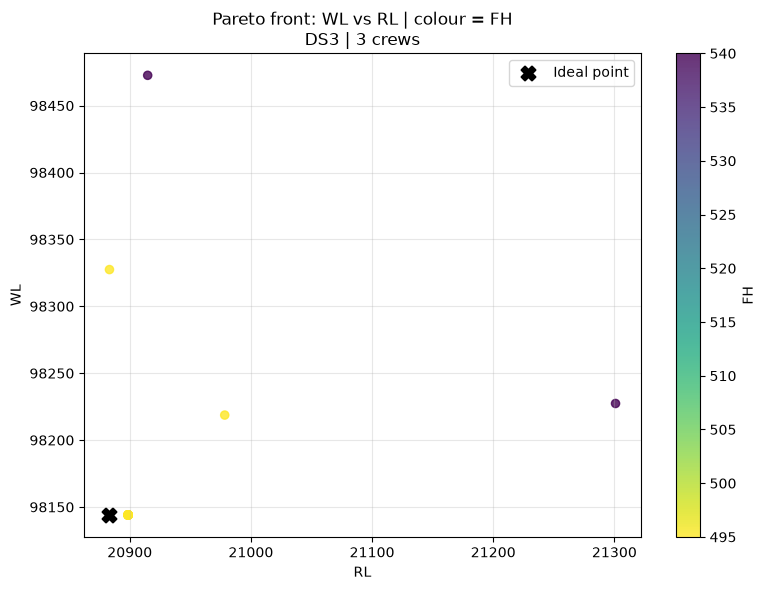

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Pareto front: WL vs RL | colour = FH\nDS3 | 3 crews'}, xlabel='RL', ylabel='WL'>)

In [18]:
# Pareto front plot using three objective functions
# Names of the objective functions to choose: FH, t95, RL, TNS, NWSECH, WL
visuals.plot_pareto_3_OF(
    data=data,
    obj1="RL",
    obj2="WL",
    color_obj="FH",
    plot_info=plot_info
)

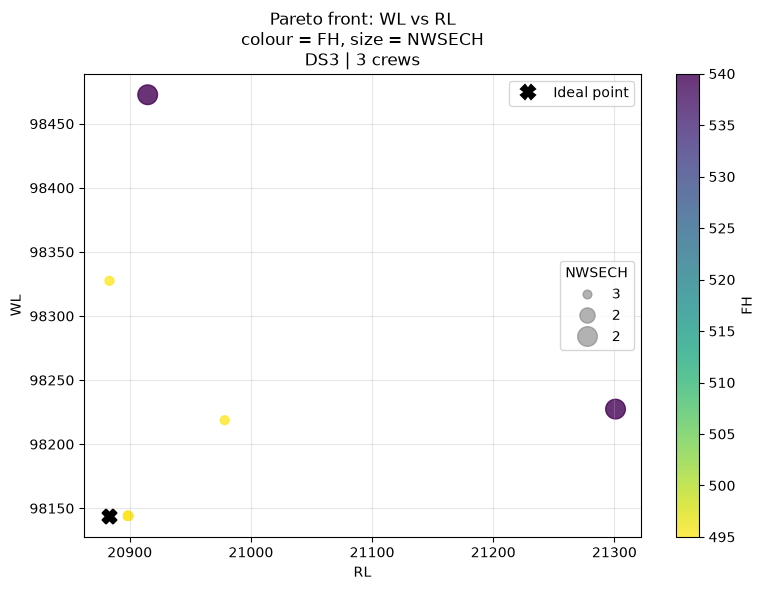

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Pareto front: WL vs RL\ncolour = FH, size = NWSECH\nDS3 | 3 crews'}, xlabel='RL', ylabel='WL'>)

In [19]:
# Pareto front plot using four objective functions
# Names of the objective functions to choose: FH, t95, RL, TNS, NWSECH, WL
visuals.plot_pareto_4_OF(
    data=data,
    obj1="RL",
    obj2="WL",
    color_obj="FH",
    size_obj="NWSECH",
    plot_info=plot_info
)

### Time Series Section

This section of the notebook is used to generate the functionality and water-loss time series for the selected solution.

Because these time series require the hydraulic results for each timestep throughout the simulation period, it is necessary to run a restoration simulation using the repair order associated with the selected solution. The simulation results are then used to calculate the functionality and water-loss time series, as well as the corresponding objective values, such as the time to 95% recovery (t95), resilience loss (RL), and water loss (WL).

In [ ]:
# Function to simulate the restoration process
def simulate_restoration(
    indexes,
    scenario,
    save_temp_inp=False,
):
    """
    Run one hydraulic restoration simulation.

    Parameters
    ----------
    indexes : list
        Permutation of damaged pipes (decision variable).

    scenario : dict
        Dictionary containing all fixed information for the
        restoration scenario.

    temp_inp : str
        Temporary INP file used during the simulation.

    save_temp_inp : bool, optional
        If True, the temporary INP is kept after the simulation.
        Otherwise it is deleted.

    Returns
    -------
    simulation : dict

        {
            "results" : SimulationResults,
            "schedule": pandas.DataFrame,
            "network" : WaterNetworkModel
        }
    """

    # Create repair schedule

    schedule = rcs.create_schedule(

        reparations=scenario["reparations"],

        dmatrix=scenario["dmatrix"],

        pipe_ids=scenario["pipe_ids"],

        indexes=indexes,

        n_crews=scenario["n_crews"],

    )

    # Generate EPANET controls

    controls = rcs.generate_controls(
        schedule
    )

    # Create temporary INP

    rcs.write_inp_controls(

        input_inp=scenario["damaged_inp"],

        output_inp=scenario["temp_inp"],

        schedule=schedule,

        new_controls=controls,

    )

    # Load temporary network

    wn = wntr.network.WaterNetworkModel(scenario["temp_inp"])

    wn.options.time.duration = scenario["duration"]
    wn.options.time.hydraulic_timestep = scenario["hydraulic_timestep"]
    wn.options.time.report_timestep = scenario["report_timestep"]
    wn.options.hydraulic.demand_model = scenario["demand_model"]
    wn.options.hydraulic.required_pressure = scenario["required_pressure"]
    wn.options.hydraulic.minimum_pressure = scenario["minimum_pressure"]
    wn.options.hydraulic.pressure_exponent = scenario["pressure_exponent"]
   
    # Run hydraulic simulation
    
    sim = wntr.sim.EpanetSimulator(wn)

    results = sim.run_sim()

    # Remove temporary INP

    if not save_temp_inp:

        try:
            os.remove(scenario["temp_inp"])

        except FileNotFoundError:
            pass

    # Return simulation

    simulation = {

        "results": results,

        "schedule": schedule,

        "network": wn,

    }

    return simulation

In [21]:
# Run one restoration simulation
simulation = simulate_restoration(
    indexes=indexes,
    scenario=scenario,
#    temp_inp=temp_inp,
    save_temp_inp=False
)

# Extract simulation results
results = simulation["results"]

demand = results.node["demand"] * 1000  # convert to L/s

pressure = results.node["pressure"]

flowrate = results.link["flowrate"]


# Supply ratio
supply_ratio = (
    demand[scenario["demand_nodes"]]
    / scenario["expected"]
)

# Objective 1 - FH
FH, FH_undersupplied = OF.OF_FH(
    supply_ratio=supply_ratio,
    dtm=scenario["dtm"]
)

# Objective 2 - t95
t95 = OF.OF_t95(
    demand=demand,
    demand_nodes=scenario["demand_nodes"],
    expected=scenario["expected"],
    dtm=scenario["dtm"]
)

# Objective 3 - RL
RL = OF.OF_RL(
    demand=demand,
    demand_nodes=scenario["demand_nodes"],
    expected=scenario["expected"],
    dtm=scenario["dtm"]
)

# Objective 4 - Time without service
TNS = OF.OF_time_no_serv(
    supply_ratio=supply_ratio,
    dtm=scenario["dtm"],
    ratio=scenario["service_ratio"]
)

# Objective 5 - NWSECH
NWSECH = OF.OF_NWSECH(
    supply_ratio=supply_ratio,
    dtm=scenario["dtm"],
    ratio=scenario["service_ratio"],
    hours=scenario["consecutive_hours"]
)

# Objective 6 - Water loss
WL = OF.OF_WL(
    demand=demand,
    emitter_nodes=scenario["emitter_nodes"],
    dt=scenario["dt"]
)

# Print results
print(f"FH      = {FH:.2f}")
print(f"t95     = {t95:.2f}")
print(f"RL      = {RL:.2f}")
print(f"TNS     = {TNS:.2f}")
print(f"NWSECH  = {NWSECH}")
print(f"WL      = {WL:.2f}")

FH      = 495.00
t95     = 6900.00
RL      = 20898.65
TNS     = 47.45
NWSECH  = 3
WL      = 98144.04


In [22]:
functionality_series = OF.system_functionality(demand, demand_nodes, expected)

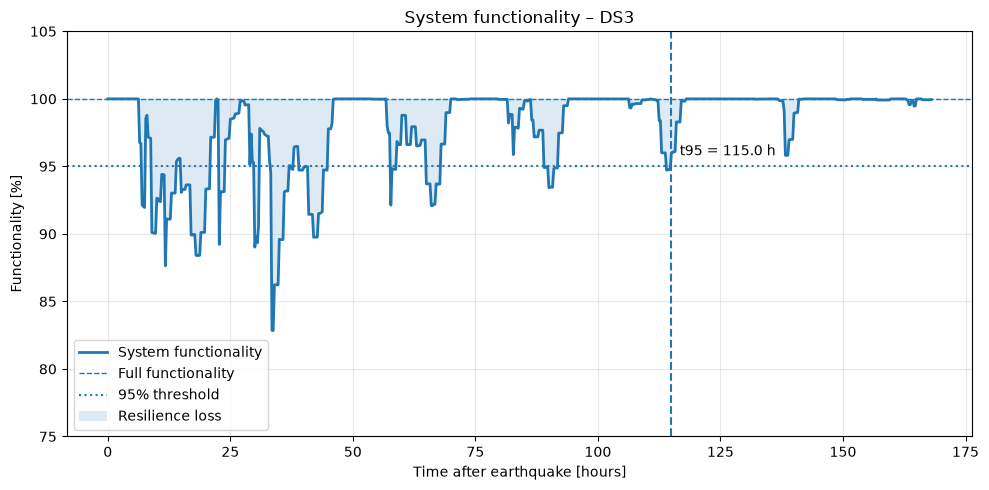

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'System functionality – DS3'}, xlabel='Time after earthquake [hours]', ylabel='Functionality [%]'>)

In [23]:
visuals.plot_functionality(
    functionality_series=functionality_series,
    t95=t95,
    scenario_name=ds_sel
)

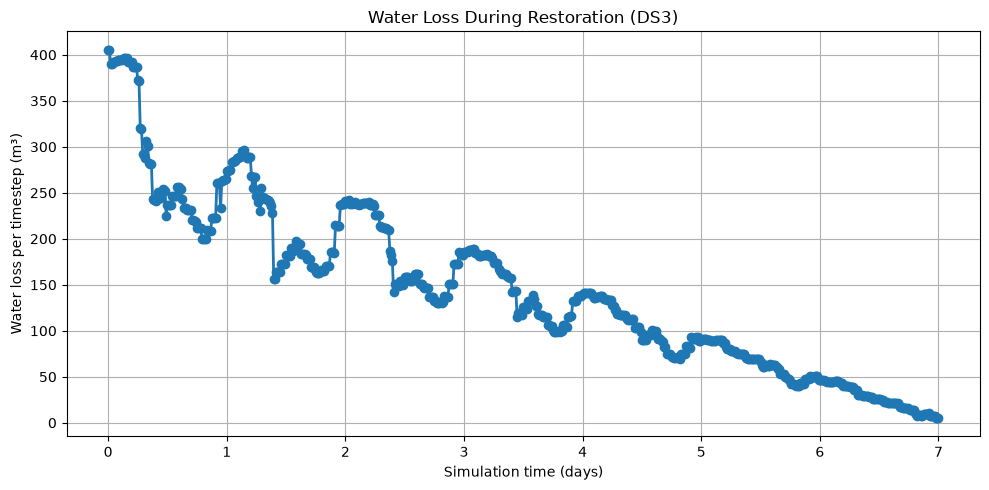

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Water Loss During Restoration (DS3)'}, xlabel='Simulation time (days)', ylabel='Water loss per timestep (m³)'>)

In [24]:
visuals.plot_water_loss(
    demand=demand,
    emitter_nodes=scenario["emitter_nodes"],
    dt=scenario["dt"],
    scenario_name=ds_sel,
#    duration_days=7
)